In [2]:
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd

from backtester.engine.costs import compute_trades

# Test 1: Simple single-stock position changes
positions = pd.Series([0, 0.2, 0.2, 0.2, 0])
trades = compute_trades(positions)
print("Single-stock trades:")
print(trades.tolist())


# Test 2: Multi-stock DataFrame
positions_multi = pd.DataFrame({
    "RELIANCE": [0.0, 0.2, 0.2, 0.0],
    "TCS":      [0.0, 0.2, 0.0, 0.0],
    "INFY":     [0.0, 0.0, 0.2, 0.0],
})
trades_multi = compute_trades(positions_multi)
print("\nMulti-stock trades:")
print(trades_multi.tolist())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Single-stock trades:
[nan, 0.2, 0.0, 0.0, 0.2]

Multi-stock trades:
[0.0, 0.4, 0.4, 0.4]


In [ ]:
"""Testing the momentum strategy returns with real data"""
from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50
from backtester.strategies.strategies import momentum_signal

# Load universe
data = load_multiple_tickers(NIFTY_50, "2020-01-01", "2024-12-31")
prices = get_close_prices(data)
prices_clean = prices.dropna(axis=1, how="all")

# Generate momentum positions
positions = momentum_signal(prices_clean, lookback_months=12, top_n=5)

# Compute trade sizes each day
trades = compute_trades(positions)

print(f"Total trading periods: {len(trades.dropna())}")
print(f"Days with no trade:     {(trades == 0).sum()}")
print(f"Days with some trade:   {(trades > 0).sum()}")
print(f"\nAverage trade size on trading days: {trades[trades > 0].mean():.4f}")
print(f"Max single-day trade size: {trades.max():.4f}")

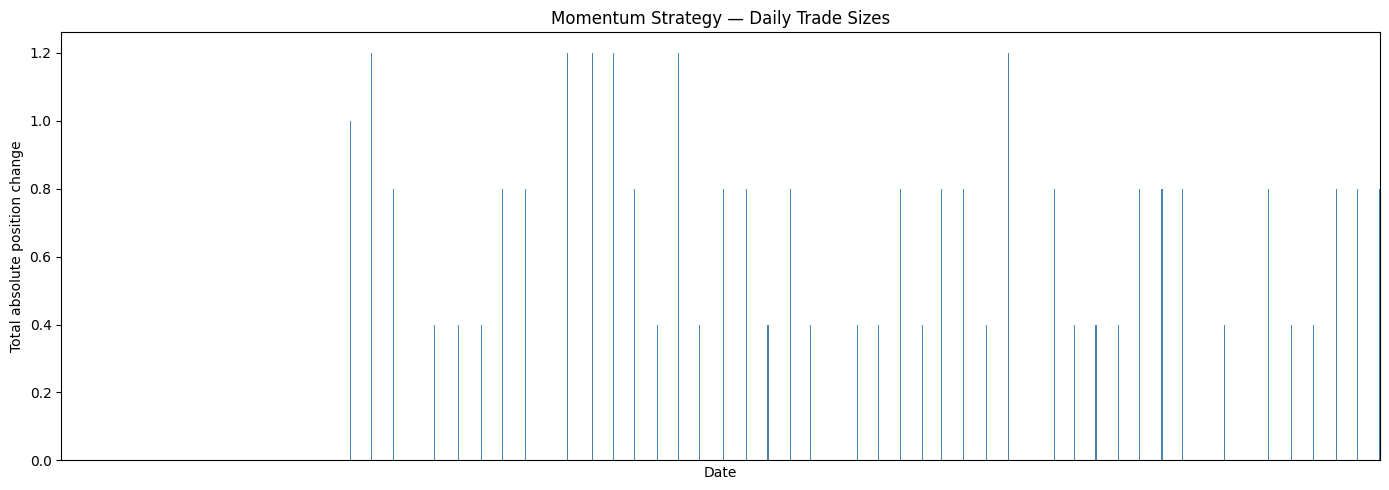

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
trades.dropna().plot(ax=ax, kind="bar", width=1.0, color="steelblue")
ax.set_title("Momentum Strategy — Daily Trade Sizes")
ax.set_ylabel("Total absolute position change")
ax.set_xticks([])  # Too many dates to show; just hide them
plt.tight_layout()
plt.show()

#### Applying costs to trades


In [3]:
from backtester.engine.costs import compute_costs, apply_costs_to_returns

# Set up a tiny test case
positions = pd.Series([0, 0.5, 0.5, 0.5, 0])
gross_returns = pd.Series([0.01, 0.01, 0.01, 0.01, 0.01])

# Compute costs
costs = compute_costs(positions)
print("Trades:        ", compute_trades(positions).tolist())
print("Costs:         ", costs.tolist())

# Apply costs to returns
net_returns = apply_costs_to_returns(gross_returns, positions)
print("\nGross returns: ", gross_returns.tolist())
print("Net returns:   ", net_returns.tolist())

Trades:         [nan, 0.5, 0.0, 0.0, 0.5]
Costs:          [nan, 0.00075, 0.0, 0.0, 0.00075]

Gross returns:  [0.01, 0.01, 0.01, 0.01, 0.01]
Net returns:    [nan, 0.00925, 0.01, 0.01, 0.00925]


### Applying Costs to Momentum strategy

In [4]:
from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50
from backtester.strategies.strategies import momentum_signal
from backtester.metrics.metrics import daily_returns, performance_report

# Load universe
data = load_multiple_tickers(NIFTY_50, "2015-01-01", "2024-12-31")
prices = get_close_prices(data)
prices_clean = prices.dropna(axis=1, how="all")

# Run momentum strategy
positions = momentum_signal(prices_clean, lookback_months=12, top_n=5)
asset_returns = daily_returns(prices_clean)
shifted = positions.shift(1)
gross_strategy_returns = (shifted * asset_returns).sum(axis=1)

# Apply costs
net_strategy_returns = apply_costs_to_returns(gross_strategy_returns, positions)

# Compare reports
gross_report = performance_report(gross_strategy_returns.dropna())
net_report = performance_report(net_strategy_returns.dropna())

print(f"{'Metric':<25} {'Gross':>10} {'Net':>10}")
print("-" * 45)
for metric in gross_report:
    g = gross_report[metric]
    n = net_report[metric]
    print(f"{metric:<25} {g:>10.4f} {n:>10.4f}")

Loading RELIANCE.NS ...
Cache for RELIANCE.NS doesn't cover requested range:
  Cached:    2020-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading TCS.NS ...
Cache for TCS.NS doesn't cover requested range:
  Cached:    2020-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading INFY.NS ...
Cache for INFY.NS doesn't cover requested range:
  Cached:    2020-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache (2014-01-01 to 2025-12-30)
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache (2014-01-01 to 2025-12-30)
Loading ITC.NS ...
Loading ITC.NS from cache (2014-01-01 to 2025-12-30)
Loading LT.NS ...
Loading LT.NS from cache (2014-01-01 to 2025-12-30)
Loading KOTAKBANK.N

##### What if costs were different

In [5]:
print(f"{'Cost rate':>10} {'Return':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 42)

for cost_rate in [0.0000, 0.0005, 0.0015, 0.0030, 0.0050]:
    net_returns = apply_costs_to_returns(gross_strategy_returns, positions, cost_per_trade=cost_rate)
    report = performance_report(net_returns.dropna())
    print(f"{cost_rate:>10.4f} {report['annualized_return']:>10.4f} "
          f"{report['sharpe_ratio']:>10.4f} {report['max_drawdown']:>10.4f}")

 Cost rate     Return     Sharpe      MaxDD
------------------------------------------
    0.0000     0.1816     0.5371    -0.4586
    0.0005     0.1778     0.5204    -0.4619
    0.0015     0.1702     0.4870    -0.4686
    0.0030     0.1589     0.4373    -0.4784
    0.0050     0.1440     0.3714    -0.4913


In [1]:
"""Comaprision of all strategies"""
import sys
sys.path.insert(0, "../src")
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt

from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50
from backtester.metrics.metrics import daily_returns, performance_report
from backtester.strategies.strategies import (
    buy_and_hold,
    moving_average_crossover,
    momentum_signal,
    positions_to_returns,
)
from backtester.engine.costs import apply_costs_to_returns

# Load universe once
data = load_multiple_tickers(NIFTY_50, "2015-01-01", "2024-12-31")
prices = get_close_prices(data).dropna(axis=1, how="all")
asset_returns = daily_returns(prices)

print(f"Universe: {prices.shape[1]} stocks")
print(f"Period:   {prices.index.min().date()} to {prices.index.max().date()}")

Loading RELIANCE.NS ...
Cache for RELIANCE.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading TCS.NS ...
Cache for TCS.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading INFY.NS ...
Cache for INFY.NS doesn't cover requested range:
  Cached:    2015-01-01 to 2024-12-30
  Requested: 2015-01-01 to 2024-12-31
  Re-downloading...
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache (2014-01-01 to 2025-12-30)
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache (2014-01-01 to 2025-12-30)
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache (2014-01-01 to 2025-12-30)
Loading ITC.NS ...
Loading ITC.NS from cache (2014-01-01 to 2025-12-30)
Loading LT.NS ...
Loading LT.NS from cache (2014-01-01 to 2025-12-30)
Loading KOTAKBANK.N

In [2]:
#building strategy posotions
# Strategy 1: Buy and hold Reliance (single stock)
bh_positions = buy_and_hold(prices["RELIANCE.NS"])

# Strategy 2: Equal-weight basket (all stocks, equal weights)
# This requires a positions DataFrame: equal weight on every stock, every day
n_stocks = prices.shape[1]
ew_positions = pd.DataFrame(1.0 / n_stocks, index=prices.index, columns=prices.columns)

# Strategy 3: MA Crossover on Reliance (single stock)
ma_positions = moving_average_crossover(prices["RELIANCE.NS"])

# Strategy 4: Momentum top-5
mom_positions = momentum_signal(prices, lookback_months=12, top_n=5)

print("All four strategies' positions built.")

All four strategies' positions built.


In [3]:
#computing gross returns for each strategy
# Single-stock strategies (Series positions)
bh_gross_returns = positions_to_returns(bh_positions, asset_returns["RELIANCE.NS"])
ma_gross_returns = positions_to_returns(ma_positions, asset_returns["RELIANCE.NS"])

# Multi-stock strategies (DataFrame positions)
ew_shifted = ew_positions.shift(1)
ew_gross_returns = (ew_shifted * asset_returns).sum(axis=1)

mom_shifted = mom_positions.shift(1)
mom_gross_returns = (mom_shifted * asset_returns).sum(axis=1)

print("Gross returns computed for all 4 strategies.")

Gross returns computed for all 4 strategies.


In [4]:
#applying costs 
bh_net_returns = apply_costs_to_returns(bh_gross_returns, bh_positions)
ma_net_returns = apply_costs_to_returns(ma_gross_returns, ma_positions)
ew_net_returns = apply_costs_to_returns(ew_gross_returns, ew_positions)
mom_net_returns = apply_costs_to_returns(mom_gross_returns, mom_positions)

print("Net (after-cost) returns computed.")

Net (after-cost) returns computed.


In [5]:
#Building the comparision table
strategies = {
    "Buy & Hold Reliance": (bh_gross_returns, bh_net_returns),
    "Equal-weight basket": (ew_gross_returns, ew_net_returns),
    "MA Crossover Reliance": (ma_gross_returns, ma_net_returns),
    "Momentum top-5": (mom_gross_returns, mom_net_returns),
}

# Build report dictionaries
results = {}
for name, (gross, net) in strategies.items():
    gross_report = performance_report(gross.dropna())
    net_report = performance_report(net.dropna())
    results[name] = {
        "gross_return": gross_report["annualized_return"],
        "net_return": net_report["annualized_return"],
        "cost_drag": gross_report["annualized_return"] - net_report["annualized_return"],
        "gross_sharpe": gross_report["sharpe_ratio"],
        "net_sharpe": net_report["sharpe_ratio"],
        "net_max_dd": net_report["max_drawdown"],
    }

# Convert to DataFrame for clean display
comparison = pd.DataFrame(results).T.round(4)
print(comparison)

                       gross_return  net_return  cost_drag  gross_sharpe  \
Buy & Hold Reliance          0.2079      0.2079     0.0000        0.5322   
Equal-weight basket          0.1954      0.1954     0.0000        0.8259   
MA Crossover Reliance        0.1161      0.1138     0.0022        0.2243   
Momentum top-5               0.1816      0.1702     0.0114        0.5371   

                       net_sharpe  net_max_dd  
Buy & Hold Reliance        0.5322     -0.4509  
Equal-weight basket        0.8259     -0.3755  
MA Crossover Reliance      0.2154     -0.4559  
Momentum top-5             0.4870     -0.4686  


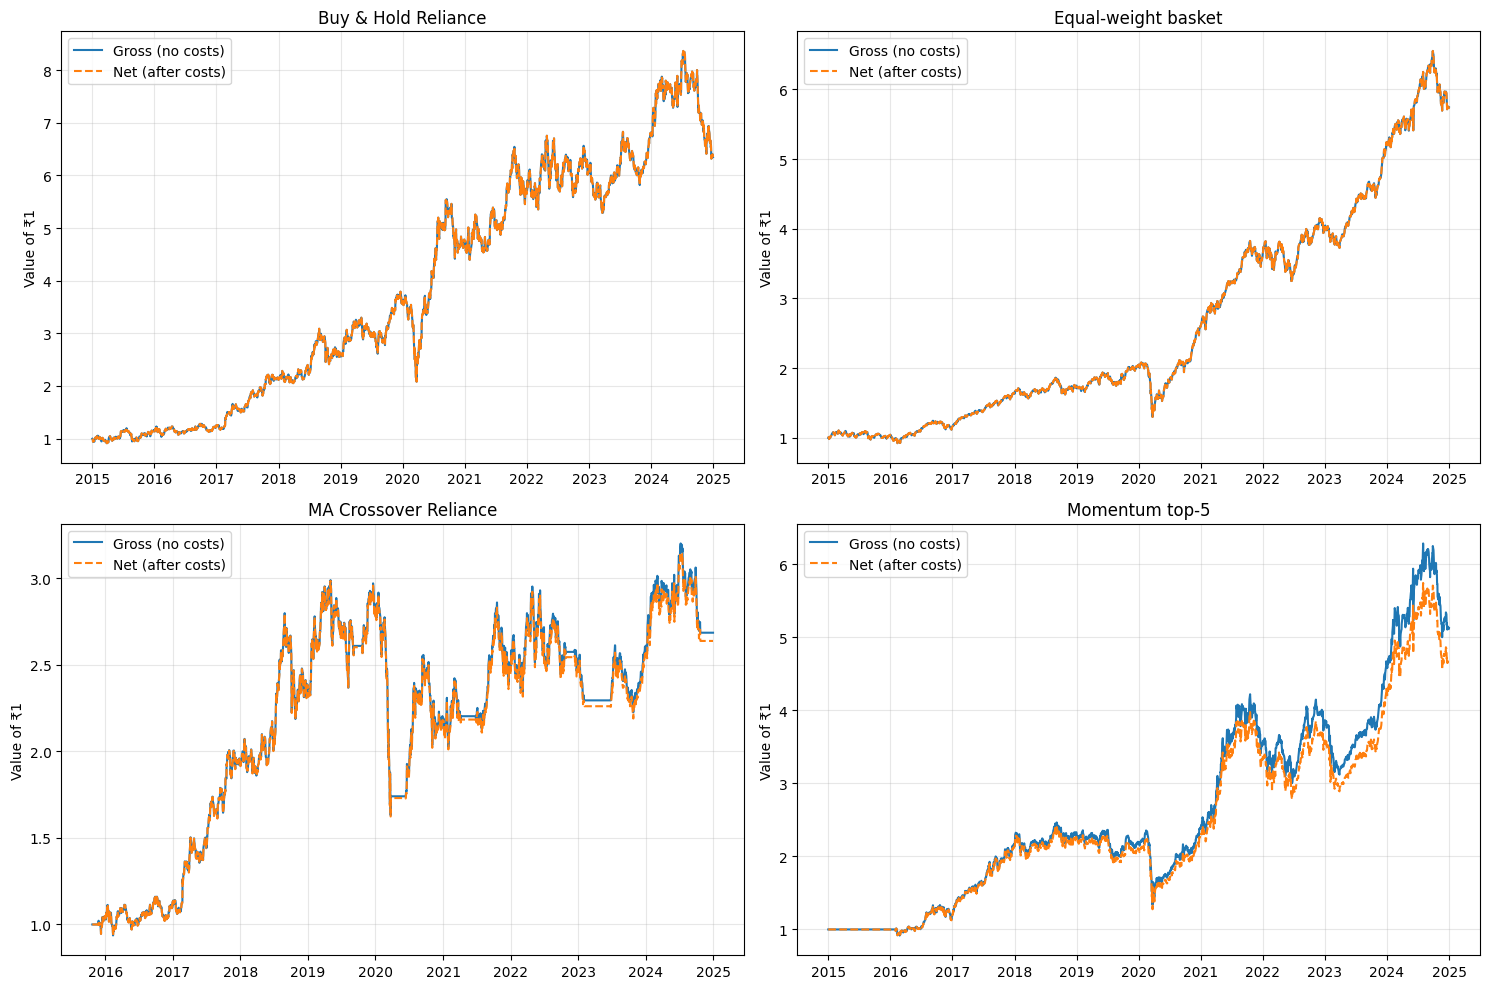

In [6]:
def equity_curve(returns):
    return (1 + returns.dropna()).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

panel_data = [
    ("Buy & Hold Reliance", bh_gross_returns, bh_net_returns),
    ("Equal-weight basket", ew_gross_returns, ew_net_returns),
    ("MA Crossover Reliance", ma_gross_returns, ma_net_returns),
    ("Momentum top-5", mom_gross_returns, mom_net_returns),
]

for ax, (name, gross, net) in zip(axes.flat, panel_data):
    gross_eq = equity_curve(gross)
    net_eq = equity_curve(net)
    
    ax.plot(gross_eq.index, gross_eq.values, label="Gross (no costs)", linewidth=1.5)
    ax.plot(net_eq.index, net_eq.values, label="Net (after costs)", linewidth=1.5, linestyle="--")
    ax.set_title(name)
    ax.set_ylabel("Value of ₹1")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
comparison.to_csv("../reports/week4_cost_comparison.csv")
print("Saved to reports/week4_cost_comparison.csv")

Saved to reports/week4_cost_comparison.csv
